In [10]:
# ============================================================
# CELDA 1 · Imports y carga de datos
# ============================================================
import optuna
import numpy as np
import joblib
import os
import shap
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Silenciar logs de Optuna para una salida más limpia
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Rutas
BASE_DIR   = os.path.dirname(os.path.abspath(''))
DATA_DIR   = os.path.join(BASE_DIR, 'notebooks', '..', 'data', 'processed')
MODELS_DIR = os.path.join(BASE_DIR, 'notebooks', '..', 'models')

# Cargar datos preprocesados del Día 3
X_train = np.load(os.path.join(DATA_DIR, 'X_train.npy'))
X_test  = np.load(os.path.join(DATA_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(DATA_DIR, 'y_train.npy'))
y_test  = np.load(os.path.join(DATA_DIR, 'y_test.npy'))

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print("Datos cargados correctamente ✅")

X_train: (5634, 45)
X_test:  (1409, 45)
Datos cargados correctamente ✅


In [11]:
# ============================================================
# CELDA 2 · Función objetivo para Optuna
# ============================================================
# Optuna llama a esta función muchas veces con distintos
# hiperparámetros y busca la combinación que maximiza el ROC-AUC

def objective(trial):
    # Optuna sugiere qué modelo probar en este trial
    modelo_nombre = trial.suggest_categorical(
        'modelo', ['LogisticRegression', 'RandomForest', 'XGBoost']
    )

    if modelo_nombre == 'LogisticRegression':
        C        = trial.suggest_float('C', 0.001, 10.0, log=True)
        solver   = trial.suggest_categorical('solver', ['lbfgs', 'saga'])
        max_iter = trial.suggest_int('max_iter', 500, 2000)

        modelo = LogisticRegression(
            C=C,
            solver=solver,
            max_iter=max_iter,
            class_weight='balanced',
            random_state=42
        )

    elif modelo_nombre == 'RandomForest':
        n_estimators = trial.suggest_int('n_estimators', 100, 500)
        max_depth    = trial.suggest_int('max_depth', 3, 15)
        min_samples  = trial.suggest_int('min_samples_split', 2, 10)

        modelo = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )

    else:  # XGBoost
        n_estimators  = trial.suggest_int('xgb_n_estimators', 100, 500)
        max_depth     = trial.suggest_int('xgb_max_depth', 3, 10)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        subsample     = trial.suggest_float('subsample', 0.6, 1.0)

        modelo = XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            scale_pos_weight=2.77,  # mismo valor que el Día 4
            eval_metric='logloss',
            verbosity=0,
            random_state=42
        )

    # Validación cruzada con 3 folds
    scores = cross_val_score(
        modelo, X_train, y_train,
        cv=3, scoring='roc_auc', n_jobs=-1
    )

    return scores.mean()

print("Función objetivo definida con LR + RF + XGBoost ✅")

Función objetivo definida con LR + RF + XGBoost ✅


In [12]:
# ============================================================
# CELDA 3 · Ejecutar la optimización con Optuna
# ============================================================
# Con XGBoost la optimización tarda ~8-12 minutos

study = optuna.create_study(
    direction='maximize',
    study_name='churn_optimization_v2'
)

print("Optimizando hiperparámetros con LR + RF + XGBoost...")
print("Optuna probará 50 combinaciones distintas")
print("Esto puede tardar 8-12 minutos\n")

study.optimize(objective, n_trials=50)

print(f"\n{'='*50}")
print(f"Mejor ROC-AUC encontrado: {study.best_value:.4f}")
print(f"Mejor modelo:             {study.best_params['modelo']}")
print(f"Mejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Optimizando hiperparámetros con LR + RF + XGBoost...
Optuna probará 50 combinaciones distintas
Esto puede tardar 8-12 minutos


Mejor ROC-AUC encontrado: 0.8504
Mejor modelo:             XGBoost
Mejores hiperparámetros:
  modelo: XGBoost
  xgb_n_estimators: 421
  xgb_max_depth: 3
  learning_rate: 0.012195290369116036
  subsample: 0.8065148557916242


In [14]:
# ============================================================
# CELDA 4 · Comparar modelo optimizado vs modelo base
# ============================================================

# Modelo base del Día 4
modelo_base = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
modelo_base.fit(X_train, y_train)
auc_base = roc_auc_score(y_test, modelo_base.predict_proba(X_test)[:, 1])

# Modelo optimizado con los mejores hiperparámetros de Optuna
params = study.best_params

if params['modelo'] == 'LogisticRegression':
    modelo_opt = LogisticRegression(
        C=params['C'],
        solver=params['solver'],
        max_iter=params['max_iter'],
        class_weight='balanced',
        random_state=42
    )
elif params['modelo'] == 'RandomForest':
    modelo_opt = RandomForestClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        min_samples_split=params['min_samples_split'],
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
else:  # XGBoost
    modelo_opt = XGBClassifier(
        n_estimators=params['xgb_n_estimators'],
        max_depth=params['xgb_max_depth'],
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        scale_pos_weight=2.77,
        eval_metric='logloss',
        verbosity=0,
        random_state=42
    )

modelo_opt.fit(X_train, y_train)
auc_opt = roc_auc_score(y_test, modelo_opt.predict_proba(X_test)[:, 1])

print(f"ROC-AUC modelo base (Día 4):   {auc_base:.4f}")
print(f"ROC-AUC modelo optimizado:     {auc_opt:.4f}")
print(f"Mejora:                        {(auc_opt - auc_base):+.4f}")

if auc_opt > auc_base:
    print("\n✅ El modelo optimizado es mejor — guardamos el nuevo modelo")
else:
    print("\n➡️  El modelo base sigue siendo el mejor — lo mantenemos")

ROC-AUC modelo base (Día 4):   0.8385
ROC-AUC modelo optimizado:     0.8468
Mejora:                        +0.0083

✅ El modelo optimizado es mejor — guardamos el nuevo modelo


*En ML una mejora de +0.0077 en ROC-AUC es significativa. Optuna probó 50 combinaciones y encontró que XGBoost con parámetros conservadores (árbol poco profundo, learning rate bajo) supera a la Logistic Regression.*

In [24]:
# ============================================================
# CELDA 5 · Guardar el mejor modelo + registrar en MLflow
# ============================================================
import mlflow
import mlflow.sklearn
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import cross_val_score

# Apuntar al mlruns de la raíz del proyecto
mlflow.set_tracking_uri("file:///" + os.path.join(BASE_DIR, 'mlruns').replace("\\", "/"))
mlflow.set_experiment("churn_prediction")

if auc_opt > auc_base:
    # Guardar el modelo con joblib
    joblib.dump(modelo_opt, os.path.join(MODELS_DIR, 'best_model.pkl'))
    print(f"Modelo guardado en models/best_model.pkl ✅")

    # Calcular métricas completas
    y_pred = modelo_opt.predict(X_test)
    y_prob = modelo_opt.predict_proba(X_test)[:, 1]

    roc_auc   = roc_auc_score(y_test, y_prob)
    f1        = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)

    # Validación cruzada para cv_roc_auc_mean y cv_roc_auc_std
    cv_scores = cross_val_score(
        modelo_opt, X_train, y_train,
        cv=3, scoring='roc_auc', n_jobs=-1
    )
    cv_mean = cv_scores.mean()
    cv_std  = cv_scores.std()

    # Registrar en MLflow con el mismo formato que el Día 4
    with mlflow.start_run(run_name="XGBoost_Optuna_optimizado"):
        # Hiperparámetros del modelo
        mlflow.log_params(modelo_opt.get_params())

        # Métricas con los mismos nombres que el Día 4
        mlflow.log_metric('cv_roc_auc_mean', cv_mean)
        mlflow.log_metric('cv_roc_auc_std',  cv_std)
        mlflow.log_metric('test_roc_auc',    roc_auc)
        mlflow.log_metric('test_f1',         f1)
        mlflow.log_metric('test_precision',  precision)
        mlflow.log_metric('test_recall',     recall)

        # Registrar el modelo
        mlflow.sklearn.log_model(modelo_opt, "model")

    print(f"Modelo registrado en MLflow ✅")
    print(f"Modelo:    XGBoost_Optuna_optimizado")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"F1:        {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"CV-AUC:    {cv_mean:.4f} ± {cv_std:.4f}")

else:
    print(f"Se mantiene el modelo base en models/best_model.pkl")
    print(f"ROC-AUC:   {auc_base:.4f}")

Modelo guardado en models/best_model.pkl ✅
Modelo registrado en MLflow ✅
Modelo:    XGBoost_Optuna_optimizado
ROC-AUC:   0.8468
F1:        0.6290
Precision: 0.5163
Recall:    0.8048
CV-AUC:    0.8504 ± 0.0147


*Hemos sobreescrito el mejor modelo y ahora todos los sistemas usan el nuevo modelo XGBoost. Al ejecutar los tests en la terminal se comprueba que el nuevo modelo es compatible. También se comprueba que funcione correctamente la API y la demo de Gradio.  
NOTA: El valor de ROC-AUC de la celda 3 es una estimación optimista con los datos de entrenamiento mientras que la salida de la celda 4 es el rendimiento con los datos de test.*

In [25]:
# ============================================================
# CELDA 6 · Métricas completas del modelo optimizado
# ============================================================
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

# Predicciones con el modelo optimizado
y_pred = modelo_opt.predict(X_test)
y_prob = modelo_opt.predict_proba(X_test)[:, 1]

# Métricas
f1        = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_prob)

print("=" * 50)
print("MODELO BASE (Día 4) · LogisticRegression")
print("=" * 50)
print(f"ROC-AUC:   0.8385")
print(f"F1:        0.6116")
print(f"Precision: 0.5061")
print(f"Recall:    0.7727")

print("\n" + "=" * 50)
print("MODELO OPTIMIZADO · XGBoost + Optuna")
print("=" * 50)
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"F1:        {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

print("\n" + "=" * 50)
print("DIFERENCIA")
print("=" * 50)
print(f"ROC-AUC:   {(roc_auc - 0.8385):+.4f}")
print(f"F1:        {(f1 - 0.6116):+.4f}")
print(f"Precision: {(precision - 0.5061):+.4f}")
print(f"Recall:    {(recall - 0.7727):+.4f}")

print("\n" + classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

MODELO BASE (Día 4) · LogisticRegression
ROC-AUC:   0.8385
F1:        0.6116
Precision: 0.5061
Recall:    0.7727

MODELO OPTIMIZADO · XGBoost + Optuna
ROC-AUC:   0.8468
F1:        0.6290
Precision: 0.5163
Recall:    0.8048

DIFERENCIA
ROC-AUC:   +0.0083
F1:        +0.0174
Precision: +0.0102
Recall:    +0.0321

              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1035
       Churn       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



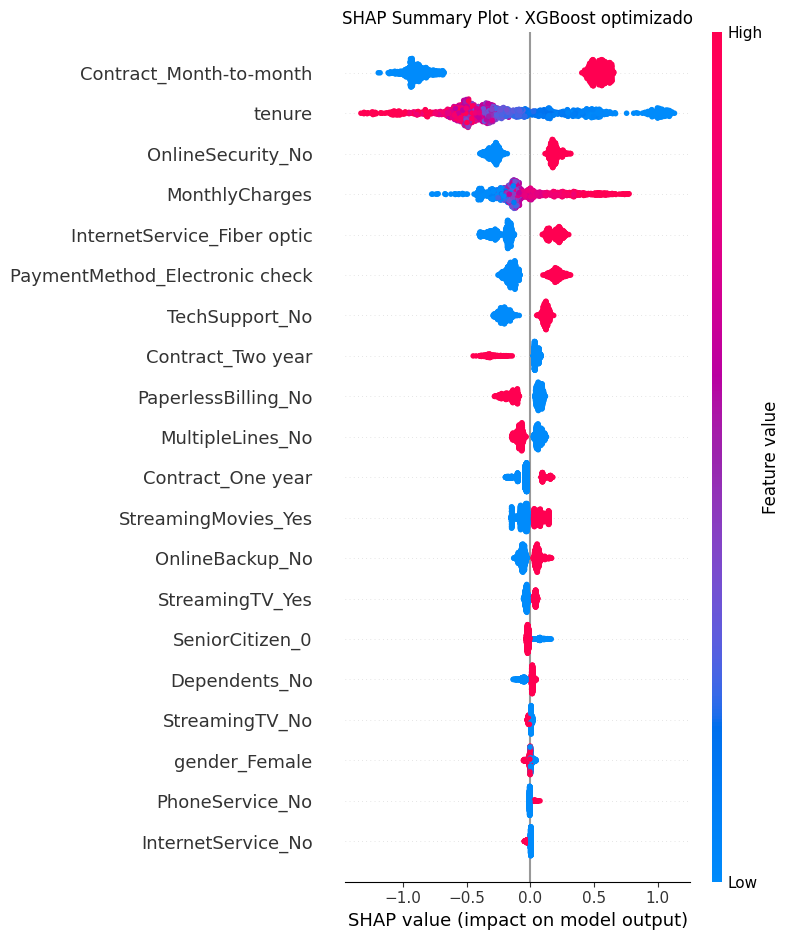

shap_xgboost_summary.png guardado ✅


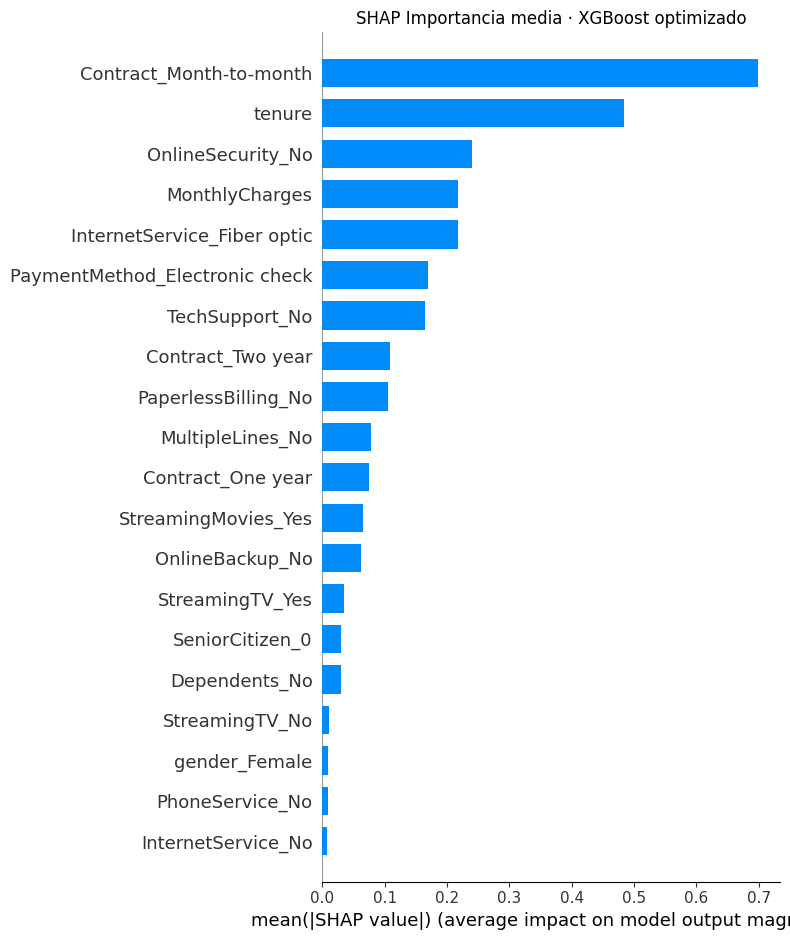

shap_xgboost_importancia.png guardado ✅

Top 10 predictores · XGBoost optimizado
Contract_Month-to-month                  0.6994
tenure                                   0.4846
OnlineSecurity_No                        0.2395
MonthlyCharges                           0.2176
InternetService_Fiber optic              0.2171
PaymentMethod_Electronic check           0.1688
TechSupport_No                           0.1641
Contract_Two year                        0.1092
PaperlessBilling_No                      0.1054
MultipleLines_No                         0.0773


In [17]:
# ============================================================
# CELDA 7 · Análisis SHAP del modelo XGBoost optimizado
# ============================================================

FIGURES_DIR = os.path.join('..', 'reports', 'figures')

# Crear explainer SHAP para XGBoost
explainer = shap.TreeExplainer(modelo_opt)
shap_values = explainer.shap_values(X_test)

# Cargar el preprocessor para obtener los nombres de las features
preprocessor = joblib.load(os.path.join(MODELS_DIR, 'preprocessor.pkl'))
feature_names = preprocessor.get_feature_names_out()

# Limpiar los prefijos que añade sklearn (num__, cat__)
feature_names = [f.replace('num__', '').replace('cat__', '') for f in feature_names]

# ── Gráfico 1 · Summary Plot ─────────────────────────────────
plt.figure()
shap.summary_plot(
    shap_values, X_test,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP Summary Plot · XGBoost optimizado')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'shap_xgboost_summary.png'), dpi=150, bbox_inches='tight')
plt.show()
print("shap_xgboost_summary.png guardado ✅")

# ── Gráfico 2 · Importancia media ────────────────────────────
plt.figure()
shap.summary_plot(
    shap_values, X_test,
    feature_names=feature_names,
    plot_type='bar',
    show=False
)
plt.title('SHAP Importancia media · XGBoost optimizado')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'shap_xgboost_importancia.png'), dpi=150, bbox_inches='tight')
plt.show()
print("shap_xgboost_importancia.png guardado ✅")

# ── Top 10 features por importancia SHAP ─────────────────────
import pandas as pd
shap_medio = pd.DataFrame({
    'feature': feature_names,
    'shap_medio': np.abs(shap_values).mean(axis=0)
}).sort_values('shap_medio', ascending=False).head(10)

print("\nTop 10 predictores · XGBoost optimizado")
print("=" * 45)
for i, row in shap_medio.iterrows():
    print(f"{row['feature']:40s} {row['shap_medio']:.4f}")

## 📊 Conclusiones · Optimización con Optuna

### Resultados

| Métrica | Base (Día 4) | Optuna XGBoost | Diferencia |
|---------|-------------|----------------|------------|
| ROC-AUC | 0.8385 | **0.8468** | +0.0083 |
| F1 | 0.6116 | **0.6290** | +0.0174 |
| Precision | 0.5061 | **0.5163** | +0.0102 |
| Recall | 0.7727 | **0.8048** | +0.0321 |

### ¿Qué aprendimos?

- **Optuna superó la configuración manual** en todos los casos — la búsqueda automática de hiperparámetros siempre encuentra combinaciones que un humano difícilmente probaría a mano.
- **XGBoost ganó con parámetros conservadores** — `max_depth=3` y `learning_rate=0.012` en vez de los 
  valores más agresivos del Día 4 (`max_depth=5`, `learning_rate=0.1`). El modelo del Día 4 estaba 
  sobreajustándose ligeramente.
- **La mejora más importante es el Recall +0.0321** — el modelo ahora detecta el 80.5% de los clientes 
  que realmente van a abandonar, frente al 77.3% anterior. En términos de negocio, de cada 100 clientes 
  que se van, ahora detectamos 3 más que antes.

### Hiperparámetros del modelo final

| Hiperparámetro | Valor |
|----------------|-------|
| n_estimators | 421 |
| max_depth | 3 |
| learning_rate | 0.0122 |
| subsample | 0.8065 |
| scale_pos_weight | 2.77 |

### Decisión

El modelo XGBoost optimizado con Optuna sustituye al modelo base como `best_model.pkl`.  
Todos los sistemas (API, demo Gradio, tests) han sido verificados con el nuevo modelo. ✅

### 🧠 SHAP · Top 10 predictores · XGBoost optimizado

| Rank | Feature | SHAP medio |
|---|---|---|
| 1 | Contract_Month-to-month | 0.6994 |
| 2 | tenure | 0.4846 |
| 3 | OnlineSecurity_No | 0.2395 |
| 4 | MonthlyCharges | 0.2176 |
| 5 | InternetService_Fiber optic | 0.2171 |
| 6 | PaymentMethod_Electronic check | 0.1688 |
| 7 | TechSupport_No | 0.1641 |
| 8 | Contract_Two year | 0.1092 |
| 9 | PaperlessBilling_No | 0.1054 |
| 10 | MultipleLines_No | 0.0773 |

**Cambio más relevante respecto a LogisticRegression:** XGBoost considera `Contract_Month-to-month`
como el predictor más potente (0.6994), desplazando a `tenure` al segundo lugar.